<a href="https://colab.research.google.com/github/Ravi-ranjan1801/ML-Lab/blob/main/ml_lab_06B_svm_tuning_for_Best_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random C values: [18.78955193 47.54064389 36.6264977  29.97305836  7.88533016  7.88412656]
C=18.79, Validation Accuracy=1.0000
C=47.54, Validation Accuracy=1.0000
C=36.63, Validation Accuracy=1.0000
C=29.97, Validation Accuracy=1.0000
C=7.89, Validation Accuracy=1.0000
C=7.88, Validation Accuracy=1.0000

Best C: 18.789551930483388
Best Validation Accuracy: 1.0

Optimal w: [-0.5 -0.5]
Optimal b: -0.0
Optimal Objective Value: 0.25


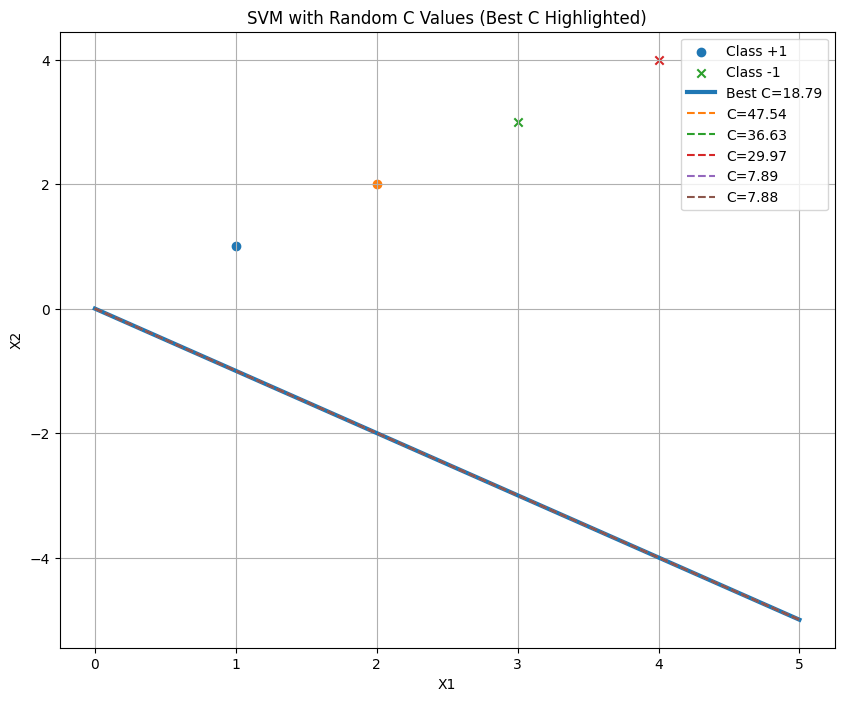

In [ ]:

!pip install scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


X = np.array([
    [1,1],
    [2,2],
    [3,3],
    [4,4]
], dtype=float)

y = np.array([1, 1, -1, -1])


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

np.random.seed(42)
C_values = np.random.uniform(0.1, 50, 6)  # 6 random values

print("Random C values:", C_values)

best_C = None
best_acc = 0
best_model = None

models = []

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    models.append((C, model))

    print(f"C={C:.2f}, Validation Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_C = C
        best_model = model

print("\nBest C:", best_C)
print("Best Validation Accuracy:", best_acc)

w = best_model.coef_[0]
b = best_model.intercept_[0]

print("\nOptimal w:", w)
print("Optimal b:", b)

# Objective value
objective_value = 0.5 * np.dot(w, w)
print("Optimal Objective Value:", objective_value)

plt.figure(figsize=(10,8))

# Plot data
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i,0], X[i,1], marker='o', label='Class +1' if i==0 else "")
    else:
        plt.scatter(X[i,0], X[i,1], marker='x', label='Class -1' if i==2 else "")

x_vals = np.linspace(0,5,100)

# Plot all models
for C, model in models:
    w = model.coef_[0]
    b = model.intercept_[0]

    y_vals = -(w[0]*x_vals + b) / w[1]

    if C == best_C:
        plt.plot(x_vals, y_vals, linewidth=3, label=f"Best C={C:.2f}")
    else:
        plt.plot(x_vals, y_vals, linestyle='--', label=f"C={C:.2f}")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM with Random C Values (Best C Highlighted)")
plt.legend()
plt.grid()

plt.show()